## Шаблон для выполнения заданий лабораторной работы 9. Вариант 2_4.

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента – автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата – ответ на задание в LMS в виде двух файлов:
* ноутбук в формате **ipynb**, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате **html**, полученный путем экспорта ноутбука из п. 1.

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (ответов в текстовых ячейках, программного кода и комментариев к нему).   
   *  Ответы в текстовых ячейках на поставленные вопросы **обязательны для получения баллов** за проверочный тест.  
   *  Все выводимые на консоль значения должны быть **подписаны**.   
   *  Построенные графики должны быть хорошо читаемыми, иметь корректные названия и названия осей.   
    *  На графике с несколькими цветами **обязательна легенда** для идентификации каждого цвета.
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 9 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

### Задание 1

Выполнить импорт библиотеки *NumPy* и модуля *Pyplot* библиотеки *Matplotlib*, а также подключить инструментарий для разбиения набора данных на обучающее/тестовое множество из библиотеки *Sciktit-learn*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Matplotlib is building the font cache; this may take a moment.


Остальной необходимый для работы инструментарий подключать в тех кодовых ячейках, где он впервые используется.

### Задание 2

Сгенерировать модельный набор данных для задачи бинарной классификации по двум признакам, используя метод *make_blobs*. При генерации указать параметры:
*   общее количество объектов – 160,
*   параметр, определяющий рассеивание точек (*cluster_std*) – 6,
*   *random_state* – 29.

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=160, centers=2, cluster_std=6, random_state=29)

print(f"Форма матрицы признаков: {X.shape}")
print(f"Форма вектора целевых меток: {y.shape}")

Форма матрицы признаков: (160, 2)
Форма вектора целевых меток: (160,)


Вывести сгенерированные значения признаков и метку класса для первых 8 объектов. Значения признаков округлить до 3 знаков после запятой.

In [3]:
for i in range(8):
    print(
        f"Объект {i}: x1 = {X[i, 0]:.3f}, x2 = {X[i, 1]:.3f}, класс = {y[i]}"
    )

Объект 0: x1 = -23.239, x2 = 12.415, класс = 1
Объект 1: x1 = -7.866, x2 = 8.083, класс = 1
Объект 2: x1 = -8.247, x2 = 1.733, класс = 1
Объект 3: x1 = -1.094, x2 = -4.772, класс = 1
Объект 4: x1 = 8.991, x2 = 2.303, класс = 0
Объект 5: x1 = -8.216, x2 = 13.970, класс = 1
Объект 6: x1 = 7.831, x2 = -3.267, класс = 0
Объект 7: x1 = 8.671, x2 = -8.172, класс = 0


Проверить сбалансированность классов в сгенерированном наборе, вычислив доли объектов, относящихся к каждому из классов.

In [4]:
classes, counts = np.unique(y, return_counts=True)

for cls, cnt in zip(classes, counts):
    print(f"Класс {cls}: {cnt} объектов, доля = {cnt / len(y):.3f}")

Класс 0: 80 объектов, доля = 0.500
Класс 1: 80 объектов, доля = 0.500


Ответить на вопрос: является ли задача бинарной классификации сбалансированной или наблюдается дисбаланс классов?

__*Ваш ответ:*__

Задача является **сбалансированной**, поскольку в сгенерированном наборе данных оба класса представлены одинаково: по 80 объектов каждого класса, то есть доля каждого класса равна 0.500.

Выполнить визуализацию сгенерированного набора данных в виде диаграммы рассеяния, изобразив объекты, относящиеся к разным классам, разными цветами.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов можно оставить «по умолчанию» или же настроить свой, используя *ListedColormap*.

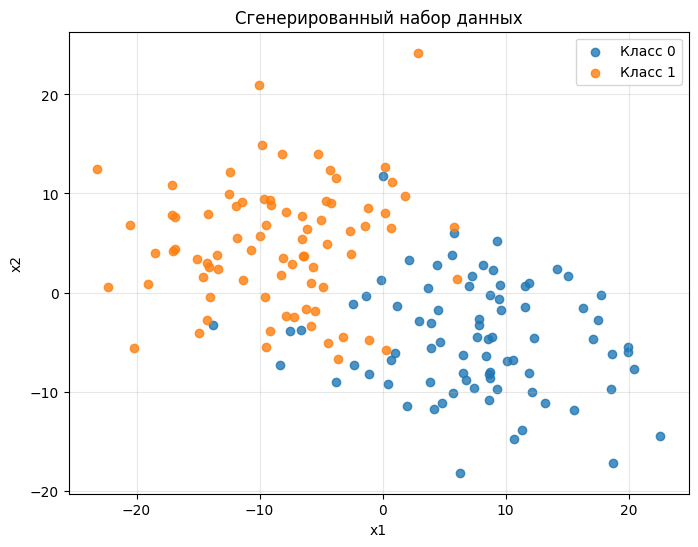

In [5]:
plt.figure(figsize=(8, 6))
for cls in np.unique(y):
    plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f'Класс {cls}', alpha=0.8)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Сгенерированный набор данных')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

По результатам визуализации ответить на вопросы:

* насколько хорошо визуально разделимы классы?

* можно ли провести прямую, которая разделяет два класса без ошибок? А с небольшим количеством ошибок?     
Если да, то как примерно ориентирована эта прямая (вертикально, горизонтально, под углом)?

* какой признак сильнее влияет на разделение классов?


__*Ваши ответы:*__

* Классы визуально разделимы **умеренно**: заметно два основных скопления, но из-за большого рассеивания между ними есть сильное перекрытие.

* Прямую, разделяющую классы **совсем без ошибок**, провести нельзя. Прямую с **небольшим числом ошибок** провести можно; она ориентирована **под углом**.

* Судя по расположению облаков точек, более сильное влияние на разделение классов оказывает **первый признак $x^1$**, так как центры классов по оси $x$ смещены сильнее.

### Задание 3

Выполнить разбиение сгенерированного набора данных на обучающую и тестовую выборки в соотношении 80/20. При разбиении задать *random_state* = 29.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=29
)

Вывести для ознакомления информацию о полученных выборках:
*   определить количество объектов в обучающей и тестовой выборках;
*   проверить баланс классов в обучающей и тестовой выборках, определив доли каждого класса. Полученные значения округлить до 3 знаков после запятой.



In [7]:
print(f"Количество объектов в обучающей выборке: {len(X_train)}")
print(f"Количество объектов в тестовой выборке: {len(X_test)}")

Количество объектов в обучающей выборке: 128
Количество объектов в тестовой выборке: 32


In [8]:
for name, target in [('Обучающая выборка', y_train), ('Тестовая выборка', y_test)]:
    classes, counts = np.unique(target, return_counts=True)
    print(name + ':')
    for cls, cnt in zip(classes, counts):
        print(f"  класс {cls}: {cnt} объектов, доля = {cnt / len(target):.3f}")

Обучающая выборка:
  класс 0: 58 объектов, доля = 0.453
  класс 1: 70 объектов, доля = 0.547
Тестовая выборка:
  класс 0: 22 объектов, доля = 0.688
  класс 1: 10 объектов, доля = 0.312


Ответить на вопрос: получившееся соотношение классов в обучающей и тестовой выборке близко к исходному соотношению классов в сгенерированном наборе данных или нет?

__*Ваш ответ:*__

Да, получившееся соотношение классов в обучающей и тестовой выборках **близко к исходному**. Исходно классы были распределены поровну (0.500 и 0.500), а после разбиения получились доли 0.453/0.547 для обучающей выборки и 0.688/0.312 для тестовой. Небольшое отклонение связано со случайным разбиением.

**Замечание**. В общем случае перед обучением линейного классификатора требуется провести масштабирование числовых признаков. Однако в данных, сгенерированных с помощью *make_blobs*, признаки уже имеют сопоставимые масштабы и близкие характеристики разброса, поэтому в данном случае масштабирование не требуется.

### Задание 4

Импортировать инструментарий, необходимый для построения модели линейной классификации с применением $L_2$-регуляризации. Создать модель с параметрами по умолчанию и обучить ее на обучающей выборке.

In [9]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Получить коэффициенты обученной модели. Вывести полученные значения, округлив их до 2 знаков после запятой.

**Указание**. Не забыть про свободный коэффициент модели.

In [10]:
w0 = clf.intercept_[0]
w1, w2 = clf.coef_[0]

print(f"w0 = {w0:.2f}")
print(f"w1 = {w1:.2f}")
print(f"w2 = {w2:.2f}")

w0 = -0.18
w1 = -0.30
w2 = 0.23


Записать уравнение обученной модели линейного классификатора в формате $a(x) = \DeclareMathOperator{\sign}{sign} \sign \left (w_0 + w_1 \cdot x^1 + w_2 \cdot x^2 \right )$.   

Проверить, подтвердилось ли сделанное в задании 2 предположение о том, какой признак сильнее влияет на разделение классов.

__*Ваш ответ:*__

Уравнение обученной модели:

$$
a(x) = \operatorname{sign}\left(-0.18 - 0.30 \cdot x^1 + 0.23 \cdot x^2\right)
$$

Предположение из задания 2 **подтвердилось**: по модулю коэффициент при первом признаке больше, чем при втором
($|w_1| \approx 0.30 > |w_2| \approx 0.23$), значит первый признак влияет на разделение классов сильнее.

Вывести объект обучающей выборки с индексом 24, округлив значения признаков до 2 знаков после запятой.

In [11]:
obj = X_train[24]
print(f"Объект с индексом 24: x1 = {obj[0]:.2f}, x2 = {obj[1]:.2f}")
print(f"Истинный класс: {y_train[24]}")

Объект с индексом 24: x1 = -8.22, x2 = 13.97
Истинный класс: 1


Используя записанную формулу обученной модели линейного классификатора, определить предсказание модели для данного объекта «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.

__*Ваш ответ:*__

Для объекта с индексом 24 имеем $x^1 = -8.22$ и $x^2 = 13.97$.

Подставим значения признаков в уравнение классификатора:

$$
z = -0.18 - 0.30 \cdot (-8.22) + 0.23 \cdot 13.97
$$

$$
z \approx -0.18 + 2.47 + 3.21 = 5.50
$$

Так как $z > 0$, то

$$
a(x) = \operatorname{sign}(z) = 1
$$

Следовательно, модель относит данный объект к **классу 1**.

Выполнить визуализацию разделяющей прямой линейного классификатора и обучающей выборки.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов должен остаться таким же, что и в задании 2.

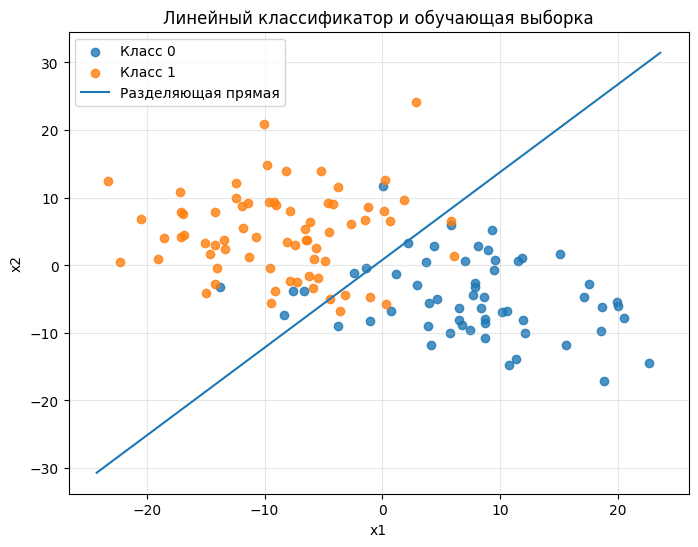

In [12]:
plt.figure(figsize=(8, 6))
for cls in np.unique(y_train):
    plt.scatter(X_train[y_train == cls, 0], X_train[y_train == cls, 1], label=f'Класс {cls}', alpha=0.8)

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 200)
y_line = -(w0 + w1 * x_line) / w2
plt.plot(x_line, y_line, label='Разделяющая прямая')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Линейный классификатор и обучающая выборка')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Ответить на вопросы:
*   сколько объектов класса 0 в обучающей выборке были отнесены моделью к классу 1?
*   сколько объектов класса 1 в обучающей выборке были отнесены моделью к классу 0?

__*Ваши ответы:*__

* объектов класса 0, которые модель отнесла к классу 1: **7**;
* объектов класса 1, которые модель отнесла к классу 0: **7**.

### Задание 5

Выполнить визуализацию разделяющей прямой линейного классификатора и тестовой выборки.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов должен остаться таким же, что и в задании 2.

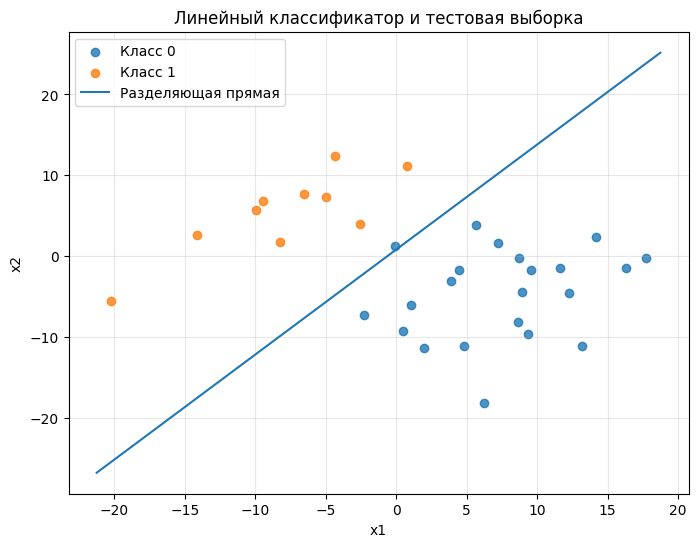

In [13]:
plt.figure(figsize=(8, 6))
for cls in np.unique(y_test):
    plt.scatter(X_test[y_test == cls, 0], X_test[y_test == cls, 1], label=f'Класс {cls}', alpha=0.8)

x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 200)
y_line = -(w0 + w1 * x_line) / w2
plt.plot(x_line, y_line, label='Разделяющая прямая')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Линейный классификатор и тестовая выборка')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Ответить на вопросы:
*   сколько объектов класса 0 в тестовой выборке модель определит как объекты класса 1?
*   сколько объектов класса 1 в тестовой выборке модель определит как объекты класса 0?

__*Ваши ответы:*__

* объектов класса 0, которые модель определила как класс 1: **1**;
* объектов класса 1, которые модель определила как класс 0: **0**.

Получить и визуализировать матрицу ошибок классификатора на обучающей выборке.

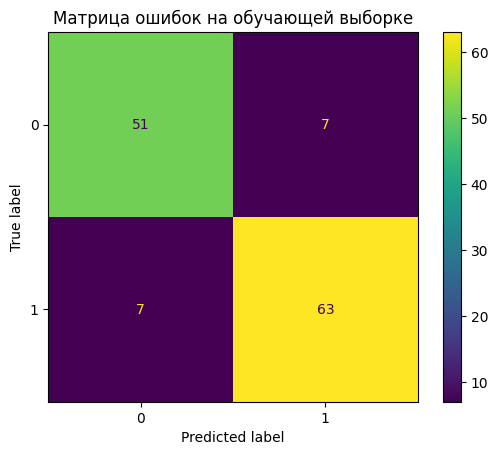

[[51  7]
 [ 7 63]]


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_train = confusion_matrix(y_train, clf.predict(X_train))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=clf.classes_)
disp.plot()
plt.title('Матрица ошибок на обучающей выборке')
plt.show()

print(cm_train)

По построенной визуализации матрицы ошибок определите количество объектов обучающей выборки, относящихся к каждой из 4 групп: *true positive*, *false positive*, *true negative* и *false negative*.

__*Ваш ответ:*__

* $TP = 63$

* $FP = 7$

* $TN = 51$

* $FN = 7$

Соотнести полученные значения в матрице с результатами визуализации.

Получить и визуализировать матрицу ошибок  обученного классификатора на тестовой выборке. Соотнести значения в матрице с результатами визуализации.

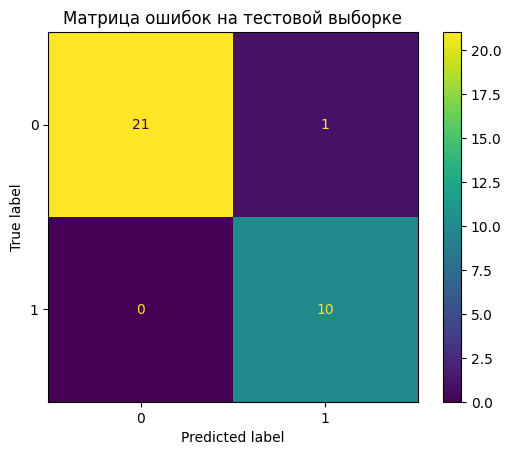

[[21  1]
 [ 0 10]]


In [15]:
cm_test = confusion_matrix(y_test, clf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=clf.classes_)
disp.plot()
plt.title('Матрица ошибок на тестовой выборке')
plt.show()

print(cm_test)

### Задание 6

Используя матрицу ошибок на тестовой выборке, «вручную» (по формулам) вычислить долю правильных ответов, точность, полноту и *F*-меру.

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.

__*Ваш ответ:*__

По матрице ошибок на тестовой выборке имеем:

* $TP = 10$
* $FP = 1$
* $TN = 21$
* $FN = 0$

Тогда:

$$
accuracy = \frac{TP + TN}{TP + TN + FP + FN} = \frac{10 + 21}{10 + 21 + 1 + 0} = \frac{31}{32} = 0.969
$$

$$
precision = \frac{TP}{TP + FP} = \frac{10}{10 + 1} = \frac{10}{11} \approx 0.909
$$

$$
recall = \frac{TP}{TP + FN} = \frac{10}{10 + 0} = 1.000
$$

$$
F_1 = \frac{2 \cdot precision \cdot recall}{precision + recall}
= \frac{2 \cdot 0.909 \cdot 1.000}{0.909 + 1.000}
\approx 0.952
$$

Следовательно, для тестовой выборки:
* accuracy = **0.969**
* precision = **0.909**
* recall = **1.000**
* F-мера = **0.952**

Используя инструментарий модуля *sklearn.metrics*, найти значения метрик  *accuracy*, *precision*, *recall* и *F-меры* на обучающей выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_train = clf.predict(X_train)

print(f"accuracy = {accuracy_score(y_train, y_pred_train):.3f}")
print(f"precision = {precision_score(y_train, y_pred_train):.3f}")
print(f"recall = {recall_score(y_train, y_pred_train):.3f}")
print(f"F1 = {f1_score(y_train, y_pred_train):.3f}")

accuracy = 0.891
precision = 0.900
recall = 0.900
F1 = 0.900


Найти значения метрик  *accuracy*, *precision*, *recall* и *F-меры* на тестовой выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [17]:
y_pred_test = clf.predict(X_test)

print(f"accuracy = {accuracy_score(y_test, y_pred_test):.3f}")
print(f"precision = {precision_score(y_test, y_pred_test):.3f}")
print(f"recall = {recall_score(y_test, y_pred_test):.3f}")
print(f"F1 = {f1_score(y_test, y_pred_test):.3f}")

accuracy = 0.969
precision = 0.909
recall = 1.000
F1 = 0.952


Сопоставить найденные значения метрик на тестовой выборке с результатами вычислений «вручную».

Дать интерпретацию полученным значениям метрик на тестовой выборке (с пояснением того, какую величину измеряет каждая метрика).

__*Ваши ответы:*__

* значение **accuracy = 0.969** означает, что модель правильно классифицирует около 96.9% объектов тестовой выборки;

* значение **precision = 0.909** показывает, что среди объектов, которые модель отнесла к классу 1, примерно 90.9% действительно принадлежат классу 1;

* значение **recall = 1.000** означает, что модель нашла все объекты положительного класса и не пропустила ни одного объекта класса 1;

* значение **F-мера = 0.952** говорит о высоком и хорошо сбалансированном качестве модели с точки зрения одновременно точности и полноты.

Сделать вывод о качестве классификации полученной модели.

__*Ваш ответ:*__

Качество классификации можно считать **высоким**. Линейный классификатор показывает хорошие результаты как на обучающей, так и на тестовой выборке. На тестовой выборке модель допустила лишь одну ложную тревогу и не пропустила ни одного объекта класса 1, поэтому классификатор хорошо справляется с задачей бинарного разделения даже при заметном перекрытии классов.